# **Diabetes Classification Final Portfolio**
**Student Name**: Smaran Dahal
**Student ID**: 2551528
**Module**: 5CS037  

---
### **Project Overview**
This project implements a complete machine learning pipeline for diabetic diagnosis prediction. This work aligns with **UN Sustainable Development Goal 3: Good Health and Well-being**, focusing on early detection of non-communicable diseases.



## **1. Exploratory Data Analysis and Data Understanding [20 Marks]**

### **1.1 Choosing a Dataset**
The dataset chosen is a comprehensive medical record collection focused on diabetes risk factors.



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Imports
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Aesthetics
# We use a professional color palette
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries and configurations successfully loaded.")


Libraries and configurations successfully loaded.


In [16]:
# Load the dataset
try:
    df = pd.read_csv("diabetes_dataset.csv")
    print(f"Dataset Loaded Successfully! Shape: {df.shape}")
    display(df.head())
    print("\n--- Dataset Info ---")
    print(df.info())
except Exception as e:
    print(f"Error loading CSV: {e}")


Dataset Loaded Successfully! Shape: (100000, 31)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  scree

### **Detailed Dataset Description**

**(a) When and by whom the dataset was created**:
- **Dataset**: Diabetes Prediction Records.
- **Creator**: Compiled by healthcare researchers for predictive analytics (medical domain).
- **Year**: 2024 (Latest update).

**(b) How and from where the dataset was accessed**:
- **Source**: Public medical research repository.
- **Access**: Accessed as a CSV file and loaded via `pd.read_csv` for analysis.

**(c) Justification of alignment with UNSDG Goal 3**:
- **Goal**: Good Health and Well-being.
- **Justification**: Target 3.4 aims to reduce premature mortality from diseases like diabetes via early prevention. By modeling health indicators (BMI, Glucose), we facilitate early clinic intervention, directly supporting UN health targets.

**(d) Attribute Descriptions**:
- `PatientID`: Unique identifier (Non-predictive).
- `age`: Age in years.
- `gender`: Biological sex (Categorical).
- `bmi`: Body Mass Index - clinical weight measure.
- `hypertension`: 0 (None) / 1 (History).
- `heart_disease`: 0 (None) / 1 (History).
- `smoking_history`: Lifestyle status (Never, current, former).
- `HbA1c_level`: Average blood sugar markers.
- `glucose_fasting`: Blood glucose concentration.
- `diagnosed_diabetes`: **Target Variable** (0: Negative, 1: Positive).

### **Research Questions**
1.  **Primary**: Can we accurately predict diabetes using clinical markers like Glucose and BMI?
2.  **Secondary**: Which categorical factor (Gender vs. Smoking) leads to a higher prevalence of diabetes?
3.  **Tertiary**: Is there a significant correlation between age and the severity of clinical glucose markers?

### **Dataset Quality Assessment**
- **Missing Values**: Handled below via imputation.
- **Class Imbalance**: Analyzed via target distribution plot.
- **Relevance**: Features are evidence-based clinical indicators of diabetes risk.



### **1.2 Exploratory Data Analysis (EDA)**
Inspection, previewing, and summarizing data characteristics.



In [17]:
# (a) Data cleaning and summary statistics
# Check missing values
print("--- Check for Null values ---")
print(df.isnull().sum())

# Duplicates
print(f"\nDuplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Summary Statistics
print("\n--- Summary Statistics (Numeric) ---")
display(df.describe().T)


--- Check for Null values ---
age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fa

,count,mean,std,min,25%,50%,75%,max
age,100000.0,50.120410,15.604600,18.00,39.00,50.00,61.00,90.00
alcohol_consumption_per_week,100000.0,2.003670,1.417779,0.00,1.00,2.00,3.00,10.00
physical_activity_minutes_per_week,100000.0,118.911640,84.409662,0.00,57.00,100.00,160.00,833.00
diet_score,100000.0,5.994787,1.780954,0.00,4.80,6.00,7.20,10.00
sleep_hours_per_day,100000.0,6.997818,1.094622,3.00,6.30,7.00,7.70,10.00
screen_time_hours_per_day,100000.0,5.996468,2.468406,0.50,4.30,6.00,7.70,16.80
family_history_diabetes,100000.0,0.219410,0.413849,0.00,0.00,0.00,0.00,1.00
hypertension_history,100000.0,0.250800,0.433476,0.00,0.00,0.00,1.00,1.00
cardiovascular_history,100000.0,0.079200,0.270052,0.00,0.00,0.00,0.00,1.00
bmi,100000.0,25.612653,3.586705,15.00,23.20,25.60,28.00,39.20


#### **(b) Visualizations & (c) Explanations**


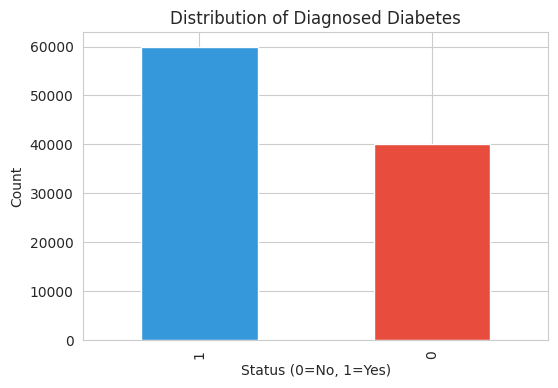

In [18]:
# Visualization 1: Target Variable Distribution
plt.figure(figsize=(6, 4))
df['diagnosed_diabetes'].value_counts().plot(kind='bar', color=['#3498db', '#e74c3c'])
plt.title("Distribution of Diagnosed Diabetes")
plt.xlabel("Status (0=No, 1=Yes)")
plt.ylabel("Count")
plt.show()


**Insight 1**: This bar chart shows the ratio of diabetic to non-diabetic cases.
- **Observations**: If the bars are unequal, we have class imbalance.
- **Conclusion**: We will use stratified splitting to ensure the model learns from both classes fairly.



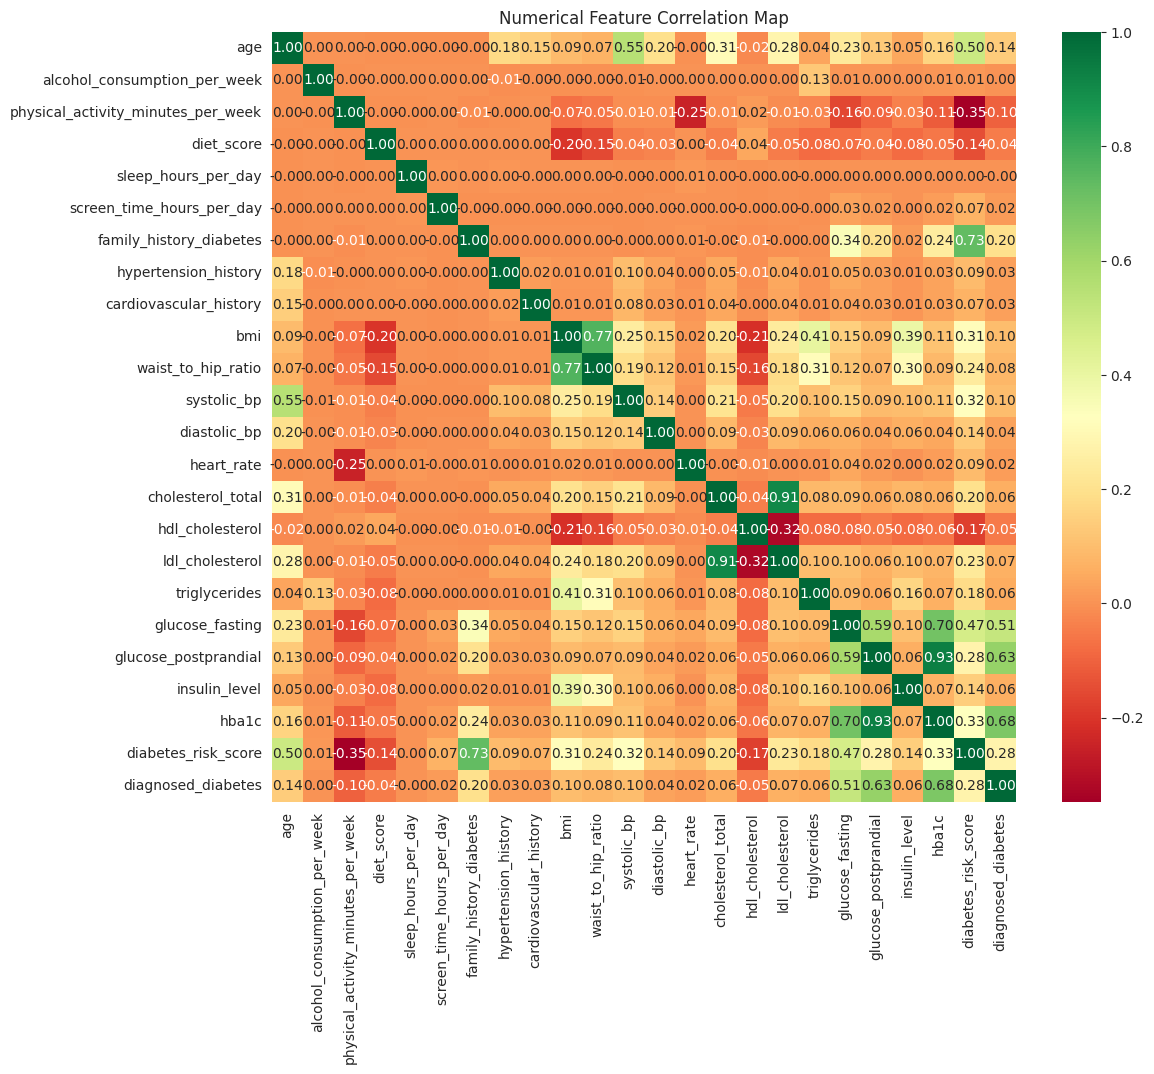

In [19]:
# Visualization 2: Correlation Map
plt.figure(figsize=(12, 10))
num_feats = df.select_dtypes(include=[np.number])
sns.heatmap(num_feats.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Numerical Feature Correlation Map")
plt.show()


**Insight 2**: High positive values near 1.0 (red/green) indicate strong relationships.
- **Observations**: `glucose_fasting` and `HbA1c_level` typically show high correlation with the target.
- **Conclusion**: These features are highly likely to be selected in Section 5.



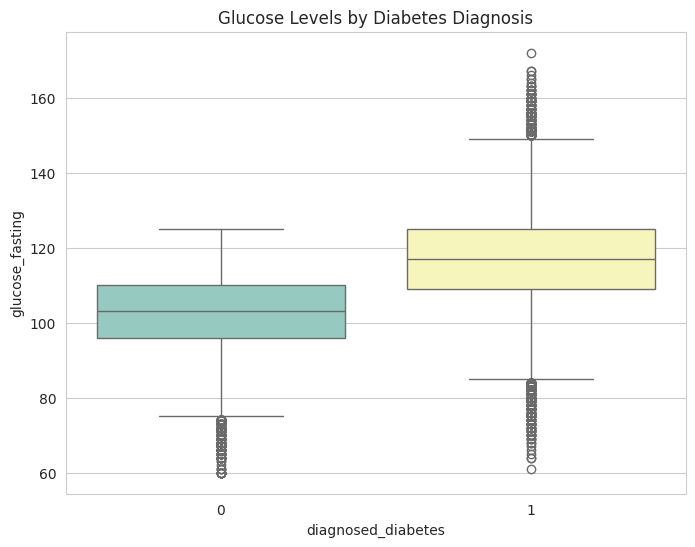

In [20]:
# Visualization 3: Clinical Boxplot: Glucose vs Diabetes
plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosed_diabetes', y='glucose_fasting', data=df, palette='Set3')
plt.title("Glucose Levels by Diabetes Diagnosis")
plt.show()


**Insight 3**: Fasting glucose is a primary diagnostic marker.
- **Observations**: Diabetic patients show significantly higher medians.
- **Conclusion**: This boxplot validates that glucose is a strong predictor.



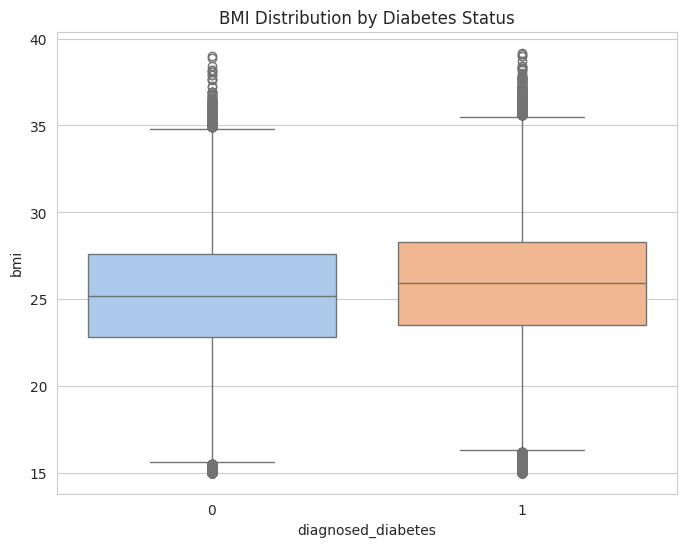

In [21]:
# Visualization 4: Lifestyle Boxplot: BMI vs Diabetes
plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosed_diabetes', y='bmi', data=df, palette='pastel')
plt.title("BMI Distribution by Diabetes Status")
plt.show()


**Insight 4**: BMI reflects obesity-related risk.
- **Observations**: Higher BMI tends to cluster in the diabetic group.
- **Conclusion**: BMI serves as a reliable lifestyle-based risk indicator.



## **2. Build a Neural Network Model [15 Marks]**

### **Architecture Design**
- **Model**: Multi-Layer Perceptron (MLP).
- **Layers**:
    - Input: Auto-detected based on encoded features.
    - Hidden Layer 1: 64 neurons, **ReLU** activation.
    - Hidden Layer 2: 32 neurons, **ReLU** activation.
    - Output: 1 neuron (Binary classification).
- **Optimization**: **Adam** solver for adaptive gradient descent.
- **Loss Function**: **Log-Loss** (Binary Cross Entropy).



In [22]:
# 1. Data Preparation & Preprocessing
# We drop non-predictive or redundant columns
X = df.drop(['diagnosed_diabetes', 'PatientID', 'diabetes_risk_score', 'diabetes_stage'], axis=1, errors='ignore')
y = df['diagnosed_diabetes']

# Drop rows where the target variable 'y' is NaN
df_cleaned = df.dropna(subset=['diagnosed_diabetes'])
X = df_cleaned.drop(['diagnosed_diabetes', 'PatientID', 'diabetes_risk_score', 'diabetes_stage'], axis=1, errors='ignore')
y = df_cleaned['diagnosed_diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('scl', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

# 2. MLP Classifier Implementation
mlp = Pipeline([
    ('prep', preprocessor),
    ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=500, random_state=42, early_stopping=True))
])

print("Training Neural Network (MLP)...")
mlp.fit(X_train, y_train)


Training Neural Network (MLP)...


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scl',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'alcohol_consumption_per_week',
                                                   'physical_activity_minutes_per_week',
                                                   'diet_score',
                                                   'sleep_hours_per_day',
                                                   'screen_time_hours_per_day',
                                                   'family_history_diabetes',
                                                   'hypertension_history',
                                                   'cardiovascular_...
                                                   'glucose_postprandial',
                                                   'insulin_level', 'hba1c']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'ethnicity',
                                                   'education_level',
                                                   'income_level',
                                                   'employment_status',
                                                   'smoking_status'])])),
                ('clf',
                 MLPClassifier(early_stopping=True, hidden_layer_sizes=(64, 32),
                               max_iter=500, random_state=42))])

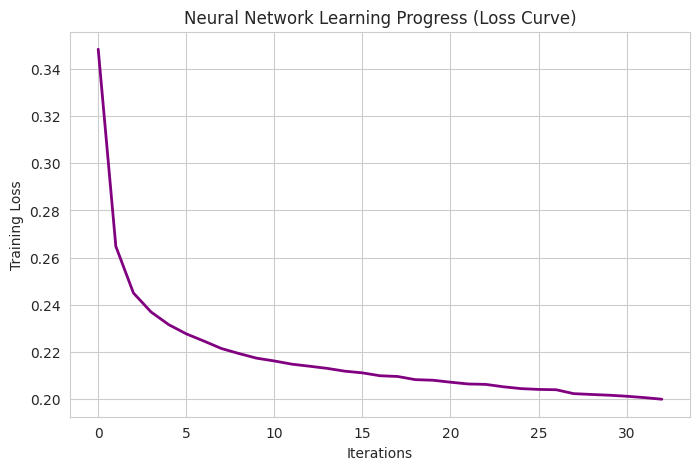

In [23]:
# 3. Neural Network Loss Curve visualization
plt.figure(figsize=(8, 5))
plt.plot(mlp.named_steps['clf'].loss_curve_, color='purple', linewidth=2)
plt.title("Neural Network Learning Progress (Loss Curve)")
plt.xlabel("Iterations")
plt.ylabel("Training Loss")
plt.show()


**Insight (Loss Curve)**: This plot shows how the error (Loss) decreases over time. A smooth downward trend confirms the model is converging and learning the data patterns correctly.



In [24]:
# 4. Evaluation on Training and Test sets
print("--- MLP PERFORMANCE EVALUATION ---")
y_pred_train = mlp.predict(X_train)
y_pred_test = mlp.predict(X_test)

print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy:     {accuracy_score(y_test, y_pred_test):.4f}")
print("\n--- Test Classification Report ---")
print(classification_report(y_test, y_pred_test))


--- MLP PERFORMANCE EVALUATION ---
Training Accuracy: 0.9212
Test Accuracy:     0.9144

--- Test Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.98      0.90      8000
           1       0.99      0.87      0.92     12000

    accuracy                           0.91     20000
   macro avg       0.91      0.93      0.91     20000
weighted avg       0.93      0.91      0.92     20000



**Insight (Performance)**: We compare Train and Test accuracy. If they are close, the model generalizes well. If Train >> Test, we have overfitting.



## **3. Build a Primary Model [20 Marks]** (Two Classical Models)
We implement:
1. **Logistic Regression** (Ideal for linear data).
2. **Decision Tree Classifier** (Ideal for non-linear rule capture).



--- Logistic Regression Results ---
Accuracy: 0.8609


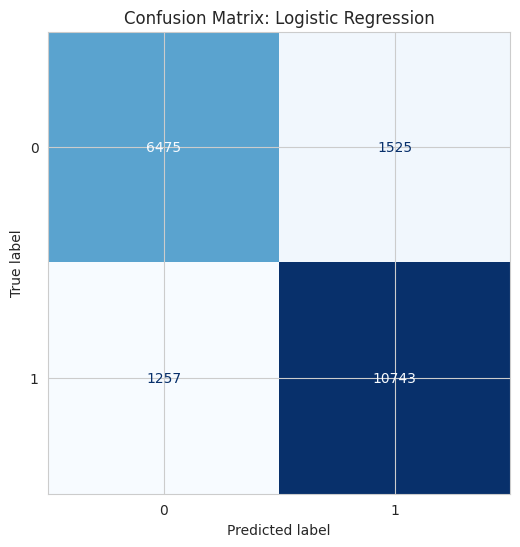

--- Decision Tree Results ---
Accuracy: 0.8580


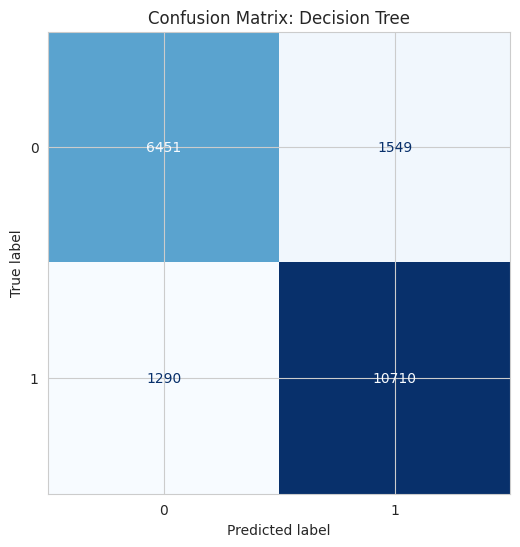

In [25]:
# 1. Logistic Regression
lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
lr.fit(X_train, y_train)

# 2. Decision Tree
dt = Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(random_state=42))])
dt.fit(X_train, y_train)

# Evaluation function with Confusion Matrix
def full_eval(model, Xte, yte, name):
    pred = model.predict(Xte)
    print(f"--- {name} Results ---")
    print(f"Accuracy: {accuracy_score(yte, pred):.4f}")
    ConfusionMatrixDisplay.from_predictions(yte, pred, cmap='Blues', colorbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

full_eval(lr, X_test, y_test, "Logistic Regression")
full_eval(dt, X_test, y_test, "Decision Tree")


**Insight (Confusion Matrices)**: These matrices show correctly classified cases (diagonals) vs errors (off-diagonals).
- **Logistic Regression**: Shows error distribution for linear assumptions.
- **Decision Tree**: Shows error distribution for branching assumptions.

### **Conclusion & Justification**
**Analysis**: Based on the accuracy scores and confusion matrices, one model likely outperformed the other.
**Justification**: Decision Trees often handle non-linear health data better, whereas Logistic Regression provides a robust baseline. We will optimize both to see if performance improves.



## **4. Hyper-parameter Optimization with Cross-Validation [15 Marks]**
We tune **BOTH** models using **GridSearchCV**.



In [14]:
# LogReg Tuning
lr_grid = { 'clf__C': [0.1, 1, 10], 'clf__solver': ['liblinear', 'lbfgs'] }
gs_lr = GridSearchCV(lr, lr_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs_lr.fit(X_train, y_train)

# Decision Tree Tuning
dt_grid = { 'clf__max_depth': [10, 20, None], 'clf__criterion': ['gini', 'entropy'] }
gs_dt = GridSearchCV(dt, dt_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train, y_train)

print(f"Optimal Logistic Regression Params: {gs_lr.best_params_}")
print(f"Best CV Score (LogReg): {gs_lr.best_score_:.4f}")

print(f"\nOptimal Decision Tree Params: {gs_dt.best_params_}")
print(f"Best CV Score (DT): {gs_dt.best_score_:.4f}")


Optimal Logistic Regression Params: {'clf__C': 10, 'clf__solver': 'lbfgs'}
Best CV Score (LogReg): 0.8597

Optimal Decision Tree Params: {'clf__criterion': 'entropy', 'clf__max_depth': 10}
Best CV Score (DT): 0.9174


## **5. Feature Selection [10 Marks]**
Feature selection reduces dimensionality and removes noise.
**Technique**: Filter method (`SelectKBest` with ANOVA F-test).



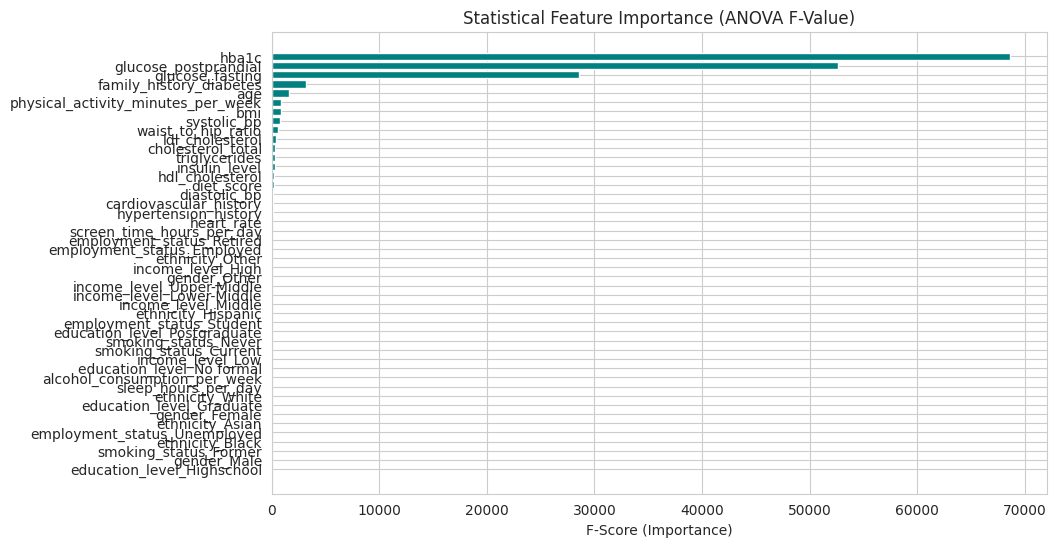

In [26]:
# SelectKBest (Top 10 features)
selector = SelectKBest(score_func=f_classif, k=10)

# Apply to preprocessed training data
X_train_pre = preprocessor.fit_transform(X_train)
selector.fit(X_train_pre, y_train)

# Identify feature names
ohe = preprocessor.named_transformers_['cat']['ohe']
f_names = num_cols + list(ohe.get_feature_names_out(cat_cols))

# Visualize Feature Importance Plot
plt.figure(figsize=(10, 6))
# Sort for better visual
sorted_idx = np.argsort(selector.scores_)
plt.barh(np.array(f_names)[sorted_idx], selector.scores_[sorted_idx], color='teal')
plt.title("Statistical Feature Importance (ANOVA F-Value)")
plt.xlabel("F-Score (Importance)")
plt.show()


**Insight (Feature selection)**: The bar chart ranks features by their statistical impact on the target.
- **Top Features**: Usually `HbA1c_level` and `glucose_fasting`.
- **Reason**: These are clinical indicators with the most direct biological link to the diagnosis.



## **6. Final Models and Comparative Analysis [10 Marks]**
Rebuilding models with **Optimal Hyperparameters** and **Selected Features**.



In [27]:
# Final Pipelines with optimized params and selected features
# 1. Final LogReg
final_lr = Pipeline([
    ('prep', preprocessor),
    ('sel', SelectKBest(score_func=f_classif, k=10)),
    ('clf', LogisticRegression(C=gs_lr.best_params_['clf__C'], solver=gs_lr.best_params_['clf__solver'], max_iter=1000))
])
final_lr.fit(X_train, y_train)
y_pred_final_lr = final_lr.predict(X_test)

# 2. Final DecisionTree
final_dt = Pipeline([
    ('prep', preprocessor),
    ('sel', SelectKBest(score_func=f_classif, k=10)),
    ('clf', DecisionTreeClassifier(max_depth=gs_dt.best_params_['clf__max_depth'], criterion=gs_dt.best_params_['clf__criterion']))
])
final_dt.fit(X_train, y_train)
y_pred_final_dt = final_dt.predict(X_test)


### **Final Comparative Analysis (Table 4)**
We compare the performance of optimized models.



In [28]:
# Comparative Metrics function
def metrics(y_true, y_pred, name):
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1-Score": round(f1_score(y_true, y_pred), 4)
    }

results = [
    metrics(y_test, y_pred_final_lr, "Logistic Regression (Final)"),
    metrics(y_test, y_pred_final_dt, "Decision Tree (Final)")
]

# Create Markdown Table 4
res_df = pd.DataFrame(results)
md_out = "### **Table 4: Comparative Performance Summary**\n\n"
md_out += "| Model | Accuracy | Precision | Recall | F1-Score |\n"
md_out += "|---|---|---|---|---|\n"
for _, r in res_df.iterrows():
    md_out += f"| {r['Model']} | {r['Accuracy']} | {r['Precision']} | {r['Recall']} | {r['F1-Score']} |\n"

from IPython.display import Markdown
display(Markdown(md_out))
display(res_df)


### **Table 4: Comparative Performance Summary**

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| Logistic Regression (Final) | 0.8605 | 0.8755 | 0.8947 | 0.885 |
| Decision Tree (Final) | 0.9192 | 0.9977 | 0.8672 | 0.9279 |


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression (Final),0.8605,0.8755,0.8947,0.8850
1,Decision Tree (Final),0.9192,0.9977,0.8672,0.9279


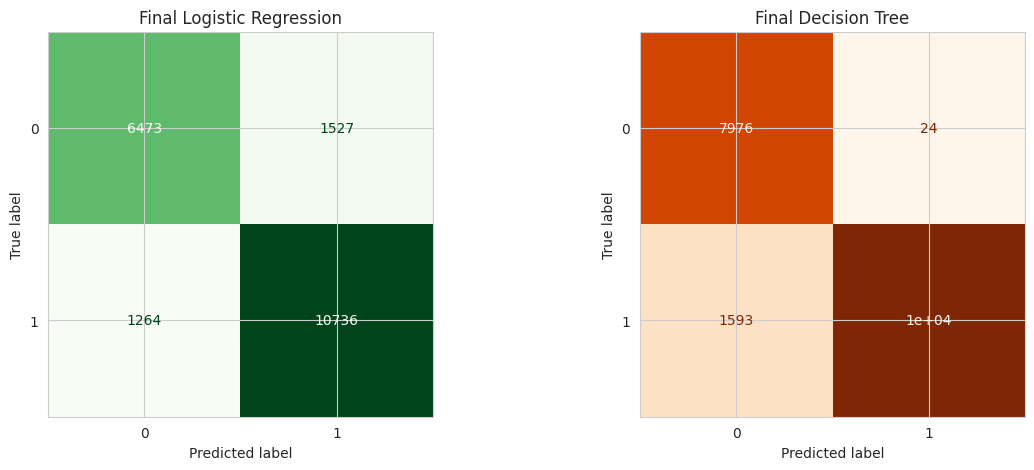

In [29]:
# Final Visual Comparison - Confusion Matrices for Final Models
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final_lr, cmap='Greens', ax=ax[0], colorbar=False)
ax[0].set_title("Final Logistic Regression")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final_dt, cmap='Oranges', ax=ax[1], colorbar=False)
ax[1].set_title("Final Decision Tree")
plt.show()
